**NOTICE**: This file utilizes configurations and pre-trained weights derived from [NV-Generate-CT](https://huggingface.co/nvidia/NV-Generate-CT). Licensed by NVIDIA Corporation under the NVIDIA Open Model License.

# MAISI CT generation through foundation model

The purpose of this notebook is to load the VAE and Rectified Flow foundation models published [here](https://huggingface.co/nvidia/NV-Generate-CT/blob/main/configs/config_network_rflow.json) and use them to generate an example CT for each patient. The model provided is not conditioned on a planning CT so the weights corresponding to the conditioning in U-Net are initialized as 0.

## Setup

In [1]:
import glob
import os
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import torch
from monai.apps.generation.maisi.networks.autoencoderkl_maisi import AutoencoderKlMaisi
from monai.apps.generation.maisi.networks.diffusion_model_unet_maisi import DiffusionModelUNetMaisi
from monai.data import Dataset, ThreadDataLoader
from monai.networks.schedulers import RFlowScheduler
from monai.transforms import (
    CenterSpatialCropd,
    Compose,
    EnsureChannelFirstd,
    EnsureTyped,
    LoadImaged,
    MapTransform,
    Orientationd,
    ScaleIntensityRanged,
    SpatialPadd,
)
from tqdm import tqdm

In [2]:
# Find project root (folder that contains .git)
ROOT = Path.cwd()
while not (ROOT / ".git").exists():
    ROOT = ROOT.parent

# Set working directory to root
os.chdir(ROOT)

print("Now working in:", Path.cwd())

Now working in: C:\Users\couch\Documents\robust-radiotherapy-planning


In [3]:
from src.data_utils import create_data_split_dict

In [4]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")

PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
# Optional Optimizations
torch.set_float32_matmul_precision("high")
torch.backends.cudnn.benchmark = True

In [7]:
# DATA LOCATION CONFIG
LATENT_TEST_DIR = "notebooks/data/latent_ct/test"
RESULT_TEST_DIR = "notebooks/data/generated_ct/test"
TEST_DIR = "notebooks/data/registered_ct/test"

# INFERENCE CONFIG
CTS_PER_PATIENT = 1
# Chunk size equal c means that the sliding window is c x c x d, where d is the image depth
CHUNK_SIZE_DECODER = 32
CHUNK_SIZE_ENCODER = 128
EVAL_BATCH_SIZE = 1
# Halos allow the sliding window to be lossless
HALO_DECODER = 2
HALO_ENCODER = 8
SPACING = (1.171875, 1.171875, 3.0)
STEPS = 30

# MODEL CONFIGS
LATENT_SCALE = 1
RFLOW_CONFIG = {
    "spatial_dims": 3,
    "in_channels": 8,
    "out_channels": 4,
    "num_channels": [64, 128, 256, 512],
    "attention_levels": [
        False,
        False,
        True,
        True,
    ],
    "num_head_channels": [0, 0, 32, 32],
    "num_res_blocks": 2,
    "use_flash_attention": True,
    "include_top_region_index_input": False,
    "include_bottom_region_index_input": False,
    "include_spacing_input": True,
    "num_class_embeds": 128,
    "resblock_updown": True,
    "include_fc": True,
}
RFLOW_NEW_WEIGHT_PATH = "notebooks/models/weights/new_diff_unet_3d_rflow-ct.pt"
RFLOW_WEIGHT_PATH = "notebooks/models/weights/diff_unet_3d_rflow-ct.pt"
SCHEDULER_CONFIG = {
    "num_train_timesteps": 1000,
    "use_discrete_timesteps": False,
    "use_timestep_transform": True,
    "sample_method": "uniform",
    "base_img_size_numel": 128 * 128 * 32,
}
VAE_CONFIG = {
    "spatial_dims": 3,
    "in_channels": 1,
    "out_channels": 1,
    "latent_channels": 4,
    "num_channels": [
        64,
        128,
        256,
    ],
    "num_res_blocks": [2, 2, 2],
    "norm_num_groups": 32,
    "norm_eps": 1e-06,
    "attention_levels": [
        False,
        False,
        False,
    ],
    "with_encoder_nonlocal_attn": False,
    "with_decoder_nonlocal_attn": False,
    "use_checkpointing": False,
    "use_convtranspose": False,
    "norm_float16": False,
    "num_splits": 1,
    "dim_split": 0,
    "save_mem": False,
}
VAE_WEIGHT_PATH = "notebooks/models/weights/autoencoder_v1.pt"

## Registration

In [8]:
# Load data dictionary
data_dict = create_data_split_dict(
    seed=42,
    train_fraction=0.8,
    folds=5,
    save=False,
)

In [9]:
# The size of the data may be inconsistent so that should be checked first
unique_shapes = set()
unique_affine = set()

for img_path in [*data_dict[0]["train"], *data_dict[0]["val"]]:
    image = nib.load(img_path)
    unique_shapes.add(image.shape)
    unique_affine.add(tuple(image.affine[i, i] for i in range(3)))

print(unique_shapes)
print(unique_affine)

{(512, 512, 130), (512, 512, 246), (512, 512, 142), (512, 512, 230), (512, 512, 108), (512, 512, 114), (512, 512, 111), (512, 512, 117), (512, 512, 242), (512, 512, 120), (512, 512, 126), (512, 512, 123), (512, 512, 129), (512, 512, 254), (512, 512, 132), (512, 512, 144), (512, 512, 226), (512, 512, 284), (512, 512, 110), (512, 512, 113), (512, 512, 119), (512, 512, 238), (512, 512, 116), (512, 512, 122), (512, 512, 125), (512, 512, 131), (512, 512, 134), (512, 512, 137), (512, 512, 222), (512, 512, 106), (512, 512, 115), (512, 512, 121), (512, 512, 118), (512, 512, 124), (512, 512, 127), (512, 512, 133)}
{(np.float64(1.171875), np.float64(1.171875), np.float64(3.0))}


In [10]:
# It's possible to center the scans around the prostate since the mask is available, but keeping it simple
transform = Compose(
    [
        LoadImaged(keys="image"),
        EnsureChannelFirstd(keys="image"),
        Orientationd(keys="image", axcodes="RAS", labels=None),
        ScaleIntensityRanged(keys="image", a_min=-1000, a_max=1500, b_min=0, b_max=1, clip=True),
        # Ensure the image is 512x512x128
        SpatialPadd(
            keys="image",
            spatial_size=(512, 512, 128),
            mode="constant",
            constant_values=0,
        ),
        CenterSpatialCropd(
            keys="image",
            roi_size=(512, 512, 128),
        ),
        EnsureTyped(keys="image", dtype=torch.float32),
    ]
)

Original shape: (512, 512, 126)
Original affine: [[1.171875 0.       0.       0.      ]
 [0.       1.171875 0.       0.      ]
 [0.       0.       3.       0.      ]
 [0.       0.       0.       1.      ]]


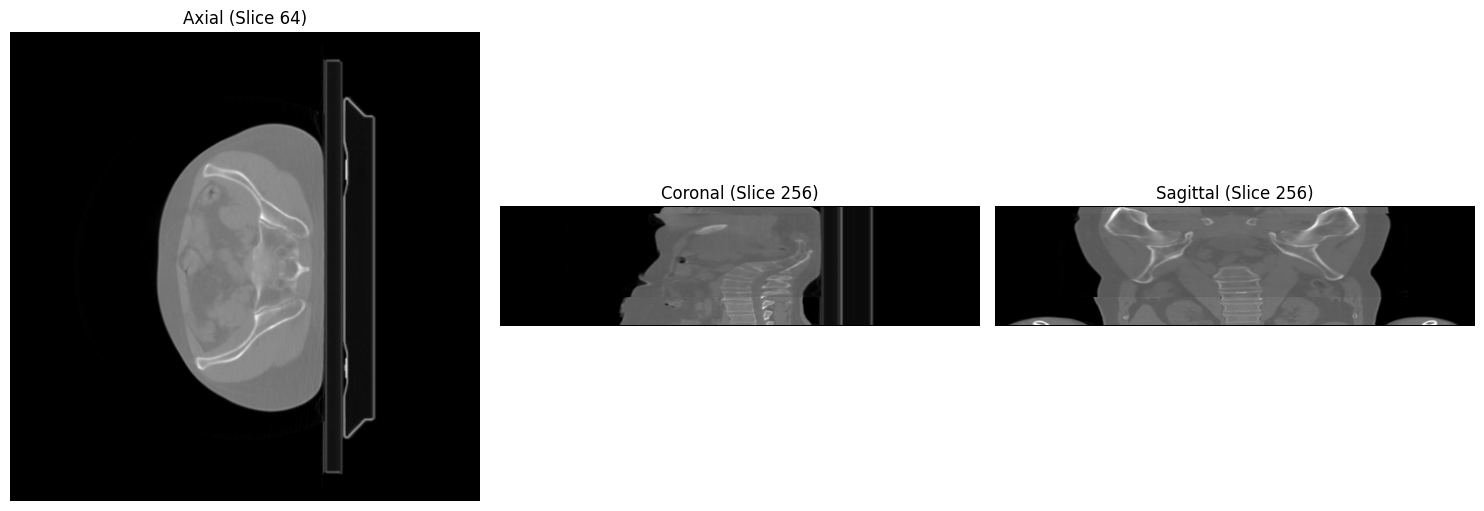

Tensor min/max: 0.0000, 1.0000


In [11]:
# Process an example image
img_path = data_dict[0]["train"][0]
img_nib = nib.load(img_path)
original_shape = img_nib.shape
original_affine = img_nib.affine
print(f"Original shape: {original_shape}")
print(f"Original affine: {original_affine}")

image_dict = {"image": img_path}
transformed_dict = transform(image_dict)
img_tensor = transformed_dict["image"]

# Matplotlib handles 32-bit float better
img_array = img_tensor.detach().cpu().float().numpy()

# Squeeze the channel dimension (C, H, W, D) -> (H, W, D)
img_array = img_array[0]

# Get middle indices for each axis
idx_h, idx_w, idx_d = [s // 2 for s in img_array.shape]

# Create the plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Axial view (Top-down)
axes[0].imshow(img_array[:, :, idx_d].T, cmap="gray", origin="lower")
axes[0].set_title(f"Axial (Slice {idx_d})")
axes[0].axis("off")

# Coronal view (Front-to-back)
axes[1].imshow(img_array[:, idx_w, :].T, cmap="gray", origin="lower")
axes[1].set_title(f"Coronal (Slice {idx_w})")
axes[1].axis("off")

# Sagittal view (Side-to-side)
axes[2].imshow(img_array[idx_h, :, :].T, cmap="gray", origin="lower")
axes[2].set_title(f"Sagittal (Slice {idx_h})")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Quick check on values
print(f"Tensor min/max: {img_tensor.min():.4f}, {img_tensor.max():.4f}")

In [12]:
def process_and_save_cts(output_dir, data_path_list):
    os.makedirs(output_dir, exist_ok=True)

    for path in tqdm(data_path_list):
        # Only save the planning CT, the others are not needed
        if "fraction_1_" not in path:
            continue

        # Run the transform
        image_dict = {"image": path}
        transformed_dict = transform(image_dict)

        # This is now (1, 512, 512, 128) in float32
        tensor_data = transformed_dict["image"]

        # Generate a clean filename
        original_name = os.path.basename(path).replace(".nii.gz", ".pt")
        save_path = os.path.join(output_dir, original_name)

        # Save as a torch tensor
        clean_tensor = tensor_data.as_tensor().clone().detach()
        torch.save(clean_tensor, save_path)

In [13]:
print("Processing test data...")
process_and_save_cts(TEST_DIR, data_dict["test"])

Processing test data...


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 444/444 [00:08<00:00, 50.18it/s]


## Sliding window inference function

In [14]:
def extract_roi(
    image,
    step,
    axis,
    chunk_size,
    halo_size,
    model_type,
    factor,
):

    image_size = image.shape[axis]

    # Calculate core image boundaries
    start_idx = step * chunk_size
    end_idx = start_idx + chunk_size

    # Calculate expanded image boundaries including the 8-voxel halo
    input_start = max(0, start_idx - halo_size)
    input_end = min(image_size, end_idx + halo_size)

    # Slice the image chunk
    if axis == 2:
        image_chunk = image[:, :, input_start:input_end, :, :].contiguous()
    else:
        image_chunk = image[:, :, :, input_start:input_end, :].contiguous()

    # Amount of padding needed to preserve the expected halo position.
    pad_before = halo_size - (start_idx - input_start)
    pad_after = halo_size - (input_end - end_idx)

    if axis == 2:
        image_chunk = torch.nn.functional.pad(
            image_chunk,
            (0, 0, 0, 0, pad_before, pad_after),
        )
    else:
        image_chunk = torch.nn.functional.pad(
            image_chunk,
            (0, 0, pad_before, pad_after, 0, 0),
        )

    if model_type == "encoder":
        padding = (start_idx - input_start) // factor
    else:
        padding = (start_idx - input_start) * factor

    return image_chunk, padding


def sliding_window_inference(
    image,
    chunk_size,
    halo_size,
    model,
    model_type,
    factor,
):
    image_size = image.shape[2]

    # Define the number of steps according to chunk_size
    num_steps = image_size // chunk_size

    # Initialize list for storing clean image chunks
    output_chunks = []

    for step_h in range(num_steps):
        # HEIGHT AXIS SPLIT
        image_chunk, padding_h = extract_roi(image, step_h, 2, chunk_size, halo_size, model_type, factor)

        # Initialize a helper list so the resulting list is 2d
        output_chunk = []

        for step_w in range(num_steps):
            # WIDTH AXIS SPLIT
            image_subchunk, padding_w = extract_roi(image_chunk, step_w, 3, chunk_size, halo_size, model_type, factor)

            # Process the chunk
            subchunk = model(image_subchunk)

            # Get the size of the chunk in the output space
            if model_type == "encoder":
                core_output = chunk_size // factor
            else:
                core_output = chunk_size * factor

            # Extract the clean sub-chunk
            clean_subchunk = subchunk[
                :, :, padding_h : (padding_h + core_output), padding_w : (padding_w + core_output), :
            ].contiguous()

            # Map the clean latent chunk into a list
            output_chunk.append(clean_subchunk)

        # Map the clean chunks into a list
        output_chunks.append(output_chunk)

    # Concat the image
    canvas = torch.cat([torch.cat(output_chunk, dim=3) for output_chunk in output_chunks], dim=2)

    return canvas

## VAE encoding

In [15]:
vae_model = AutoencoderKlMaisi(**VAE_CONFIG).to(DEVICE)

vae_state_dict = torch.load(VAE_WEIGHT_PATH)
vae_model.load_state_dict(vae_state_dict)

<All keys matched successfully>

In [16]:
# Class for loading processed .pt files
class LoadProcessedTensord(MapTransform):
    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            # Load the .pt file directly into memory
            # weights_only=True helps with security/speed
            d[key] = torch.load(d[key], weights_only=True)
        return d

In [17]:
# Transform to be used for evaluation
standard_transform = Compose(
    [
        LoadProcessedTensord(keys=["image"]),
        EnsureTyped(keys=["image"], track_meta=False),
    ]
)

# Build the dataset dictionary
test_files = []
for f in sorted(glob.glob(os.path.join(TEST_DIR, "*.pt"))):
    filename = os.path.basename(f)

    # Full path for the specific fraction
    full_save_path = os.path.join(LATENT_TEST_DIR, filename)

    test_files.append(
        {
            "image": f,
            "save_path": full_save_path,
        }
    )

# Create Dataset
test_ds = Dataset(data=test_files, transform=standard_transform)

# Create DataLoader
test_loader = ThreadDataLoader(test_ds, batch_size=EVAL_BATCH_SIZE, shuffle=False, pin_memory=True)

In [18]:
def vae_encoder_wrapper(image_patch):
    # Use the mean of the distribution for determinism
    mu, _ = vae_model.encode(image_patch)
    return mu

In [19]:
# Prepare the model and output folder
vae_model.eval()
os.makedirs(LATENT_TEST_DIR, exist_ok=True)

# Define the number of windows to compute
num_steps = 512 // CHUNK_SIZE_ENCODER

with torch.no_grad():
    for batch in tqdm(test_loader):
        # Get the image
        image = batch["image"].to(DEVICE, non_blocking=True)

        # Process the image through a sliding window
        canvas = sliding_window_inference(image, CHUNK_SIZE_ENCODER, HALO_ENCODER, vae_encoder_wrapper, "encoder", 4)

        # Save the image
        torch.save(canvas[0, ...].cpu(), batch["save_path"][0])

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:54<00:00,  3.65s/it]


## CT generation

In [20]:
# Class for the Planning CTs dataset (latent representations)
class PatientConditionDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.samples = []

        self.samples = sorted(glob.glob(os.path.join(root_dir, "Patient_*")))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        f_path = self.samples[idx]
        f_data = torch.load(f_path, weights_only=True)

        return f_data, f_path

In [21]:
latent_test_dataset = PatientConditionDataset(LATENT_TEST_DIR)

latent_test_loader = ThreadDataLoader(latent_test_dataset, batch_size=1, shuffle=False, pin_memory=True)

In [22]:
rflow_model = DiffusionModelUNetMaisi(**RFLOW_CONFIG).to(DEVICE)

# Load the foundation model weights
rflow_state_dict = torch.load(RFLOW_WEIGHT_PATH, weights_only=False)["unet_state_dict"]

first_layer_key = "conv_in.conv.weight"
pretrained_weights = rflow_state_dict[first_layer_key]

# Create new weights for the convolutions since it now has extra channels
new_weights = torch.zeros(rflow_model.state_dict()[first_layer_key].shape)
new_weights[:, :4, ...] = pretrained_weights  # The noise part
new_weights[:, 4:, ...] = 0.0  # The Planning CT part

# Update the dictionary and load
rflow_state_dict[first_layer_key] = new_weights
torch.save(rflow_state_dict, RFLOW_NEW_WEIGHT_PATH)

# Load the dictionary from disk to make sure it's saved correctly
rflow_state_dict = torch.load(RFLOW_NEW_WEIGHT_PATH)
rflow_model.load_state_dict(rflow_state_dict)

<All keys matched successfully>

In [23]:
noise_scheduler = RFlowScheduler(**SCHEDULER_CONFIG)
noise_scheduler.set_timesteps(STEPS, input_img_size_numel=SCHEDULER_CONFIG["base_img_size_numel"])

In [24]:
# Prepare the models
vae_model.eval()
rflow_model.eval()

# Prepare the class and spacing tensors
# 2 corresponds to a CT without contrast
class_labels = torch.tensor([2], dtype=torch.long).to(DEVICE)
spacing_tensor = torch.tensor([[*SPACING]], dtype=torch.float32).to(DEVICE)

for f_data, f_path in tqdm(latent_test_loader):
    f_data = f_data.to(DEVICE)

    # Each patient should have their own folder
    patient_id = os.path.basename(f_path[0]).split("_fraction_")[0]
    patient_dir = os.path.join(RESULT_TEST_DIR, patient_id)
    os.makedirs(patient_dir, exist_ok=True)

    for i in range(1, CTS_PER_PATIENT + 1):
        z_t = torch.randn_like(f_data).to(DEVICE) * LATENT_SCALE

        # Iterate through the timesteps defined by the scheduler
        for t in noise_scheduler.timesteps:
            # Prepare t for the model (batch dimension and device)
            t_tensor = torch.tensor([t]).to(DEVICE)

            # Create the 8-channel input
            # Combine current state (z_t) with the anchor (f_data)
            model_input = torch.cat([z_t, f_data], dim=1)

            # Predict Velocity (v)
            with torch.no_grad():
                v_pred = rflow_model(model_input, t_tensor, class_labels=class_labels, spacing_tensor=spacing_tensor)

            # Update z_t using the scheduler
            z_t, _ = noise_scheduler.step(v_pred, t, z_t)

        # Map from latent representation to CT
        with torch.no_grad():
            canvas = (
                sliding_window_inference(z_t, CHUNK_SIZE_DECODER, HALO_DECODER, vae_model.decode, "decoder", 4)
                / LATENT_SCALE
            )

        # Rescale the CT to -1000:1500
        reconstructed_ct = torch.clamp(2500 * canvas - 1000, -1000, 1500).round().int()

        # Save the scan
        torch.save(reconstructed_ct[0, ...].cpu(), os.path.join(patient_dir, f"{patient_id}_gen_{i}.pt"))

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [03:24<00:00, 13.60s/it]
